In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc, average_precision_score,
    precision_score, recall_score, f1_score, roc_auc_score
)

from config.paths import (
    X_TRAIN, X_TEST, Y_TRAIN, Y_TEST,
    XGBOOST_METRICS, XGBOOST_MODEL, XGBOOST_CHARTS
)

XGBOOST_CHARTS.mkdir(parents=True, exist_ok=True)

X_train = pd.read_csv(X_TRAIN)
X_test = pd.read_csv(X_TEST)
y_train = pd.read_csv(Y_TRAIN).squeeze()
y_test = pd.read_csv(Y_TEST).squeeze()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8000, 7), (2000, 7), (8000,), (2000,))

In [5]:
import re

def clean_col(col):
    return re.sub(r'[\[\]<]', '', col).strip()

X_train.columns = [clean_col(c) for c in X_train.columns]
X_test.columns = [clean_col(c) for c in X_test.columns]

X_train.columns.tolist()

['Air temperature K',
 'Process temperature K',
 'Rotational speed rpm',
 'Torque Nm',
 'Tool wear min',
 'Type_L',
 'Type_M']

In [6]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# scale_pos_weight = ratio of negative to positive class in training data
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

scoring = ['precision', 'recall', 'f1', 'roc_auc', 'average_precision']
cv_results = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring)

cv_summary = pd.DataFrame({
    metric: [cv_results[f'test_{metric}'].mean(), cv_results[f'test_{metric}'].std()]
    for metric in scoring
}, index=['mean', 'std']).T

print(cv_summary)

scale_pos_weight: 28.52
                       mean       std
precision          0.633323  0.052947
recall             0.778704  0.084096
f1                 0.696960  0.059014
roc_auc            0.971325  0.014591
average_precision  0.780938  0.064737


In [7]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.68      0.79      0.73        68

    accuracy                           0.98      2000
   macro avg       0.83      0.89      0.86      2000
weighted avg       0.98      0.98      0.98      2000



In [8]:
test_metrics = {
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_proba),
    'average_precision': average_precision_score(y_test, y_proba),
}

metrics_df = cv_summary.copy()
metrics_df['test'] = [test_metrics[m] for m in metrics_df.index]
metrics_df = metrics_df.rename(columns={'mean': 'cv_mean', 'std': 'cv_std'})

metrics_df.to_csv(XGBOOST_METRICS)
metrics_df

,cv_mean,cv_std,test
precision,0.633323,0.052947,0.675000
recall,0.778704,0.084096,0.794118
f1,0.696960,0.059014,0.729730
roc_auc,0.971325,0.014591,0.962527
average_precision,0.780938,0.064737,0.811873


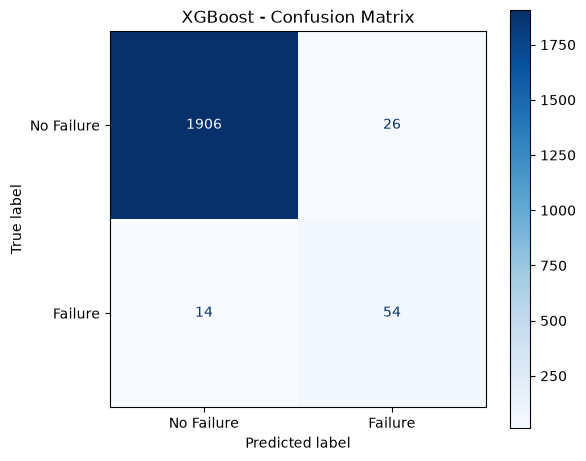

In [9]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Failure', 'Failure'])
 
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('XGBoost - Confusion Matrix')
plt.tight_layout()
plt.savefig(XGBOOST_CHARTS / "confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
